In [8]:
# import modules
import datacube
import joblib
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from dea_tools.classification import sklearn_flatten, sklearn_unflatten 
from dea_tools.datahandling import load_ard
from dea_tools.plotting import display_map, rgb
from odc.algo import mask_cleanup
from datacube.utils.cog import write_cog
from dea_tools.plotting import display_map

In [9]:
import sklearn
print(sklearn.__version__)

1.5.2


In [10]:
#define colour scale for plotting 
colours = [(0.87, 0, 0), (1, 1, 0.73), (0.165, 0.615, 0.957)]
cmap = LinearSegmentedColormap.from_list('fmc', colours, N=256)

In [11]:
dc = datacube.Datacube(app='fmc')

In [12]:
def classify_FMC(data, model):
    """
    - data (xarray.Dataset): Sentinel-2 dataset containing required bands and optional multiple time steps. 
        
    - model (sklearn model): A pre-trained model for classification.
    
    Returns:
    - xarray.Dataset: A dataset containing the classified FMC results.
"""
    #calculate NDVI and NDII

    data['ndii']=((data.nbart_nir_1-data.nbart_swir_2)/(data.nbart_nir_1+data.nbart_swir_2))
    data['ndvi']=((data.nbart_nir_1-data.nbart_red)/(data.nbart_nir_1+data.nbart_red))

    # change order of variables to be the same as the model expects
    data_neworder = data[['ndvi','ndii', 'nbart_blue','nbart_green','nbart_red','nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3']] 
    
    #flattern the data using SKlearn_flatten
    data_flat = sklearn_flatten(data_neworder)
    
    #classify the data using the model
    print("predicting...")
    out_class = model.predict(data_flat)
    
    #return_classification to original shape
    #transpose because coords sideways when moving from Numpy to Xarray
    returned_result = sklearn_unflatten(out_class, data).transpose()
    
    #make results a dataset
    dataset_result = xr.Dataset({'LFMC':returned_result}, coords=data.coords, attrs=data.attrs)
    
    #return
    return dataset_result

In [13]:
# import model
model = joblib.load('/home/jovyan/gdata1/projects/Hazards/Fuel_moisture/RF_AllBands_noLC_DEA_labeless.joblib')


In [14]:
point_x, point_y = (-35.3745, 148.2445) 

lat = (point_x - 0.05, point_x + 0.05)
lon = (point_y - 0.05, point_y + 0.05)

# Display area on map
display_map(x=lon, y=lat)

In [15]:

df = dc.load(product=['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
            measurements= ['nbart_blue','nbart_green','nbart_red','oa_fmask', 'nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3', 'oa_nbart_contiguity'],
            x=lon,
            y=lat,
            resolution=(-20, 20),
            time = ('2021-05-01','2021-05-15', ),
            resampling={"*": "bilinear"},

            output_crs= 'EPSG:3577')

# 
# Check if the dataset is loaded
df

<xarray.Dataset> Size: 147MB
Dimensions:              (time: 21, y: 610, x: 521)
Coordinates:
  * time                 (time) datetime64[ns] 168B 2021-05-02T00:16:23.84051...
  * y                    (y) float64 5kB -3.951e+06 -3.951e+06 ... -3.963e+06
  * x                    (x) float64 4kB 1.464e+06 1.464e+06 ... 1.475e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_green          (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_red            (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    oa_fmask             (time, y, x) uint8 7MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_red_edge_1     (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_red_edge_2     (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_red_edge_3     (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_nir_1          (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_nir_2          (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_swir_2         (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    nbart_swir_3         (time, y, x) int16 13MB -999 -999 -999 ... -999 -999
    oa_nbart_contiguity  (time, y, x) uint8 7MB 255 255 255 255 ... 255 255 255
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [16]:
df.oa_nbart_contiguity.attrs["flags_definition"]

{'contiguous': {'bits': [0], 'values': {'0': False, '1': True}}}

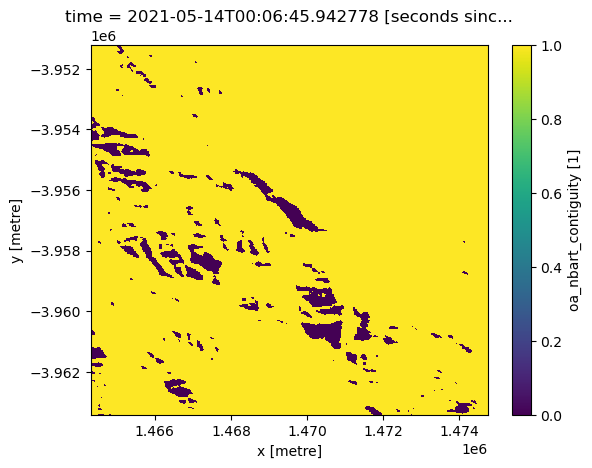

In [17]:
df.oa_nbart_contiguity.isel(time=19).plot()

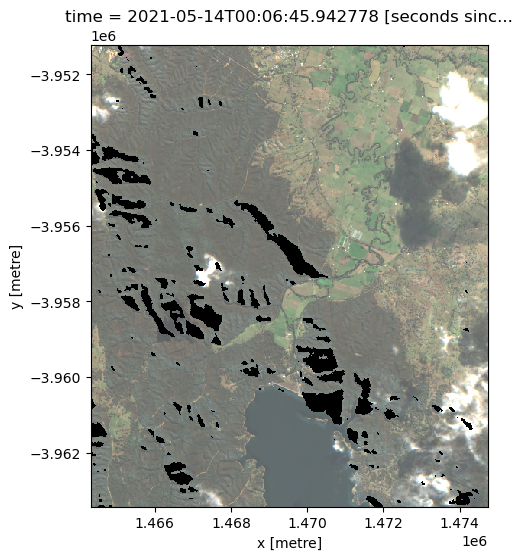

In [18]:
rgb(df, index=19)

In [19]:
# Define masks. seperate cloud + shadow mask from water+ no_data mask becasue we want to do buffering of could+shadow but not water+no_data

cloud_mask = (df.oa_fmask == 2) | (df.oa_fmask == 3)
water_mask = (df.oa_fmask == 0) | (df.oa_nbart_contiguity == 0)


In [20]:
#perfrom 1 pixel opening on cloud + shadow. three pixle dilation 
better_cloud_mask = mask_cleanup(mask=cloud_mask, mask_filters=[("opening", 1),("dilation", 3)])

#drop fmask from dataset before we classify
df = df.drop(['oa_fmask', 'oa_nbart_contiguity'])

/tmp/ipykernel_709/696312390.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df = df.drop(['oa_fmask', 'oa_nbart_contiguity'])


In [21]:
df = df.where(df > -999, 0)

In [22]:
#perfrom calssification of data usinf model defined above
FMC_data = classify_FMC(df, model)

predicting...


In [23]:
df

<xarray.Dataset> Size: 240MB
Dimensions:           (time: 21, y: 610, x: 521)
Coordinates:
  * time              (time) datetime64[ns] 168B 2021-05-02T00:16:23.840514 ....
  * y                 (y) float64 5kB -3.951e+06 -3.951e+06 ... -3.963e+06
  * x                 (x) float64 4kB 1.464e+06 1.464e+06 ... 1.475e+06
    spatial_ref       int32 4B 3577
Data variables:
    nbart_blue        (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_green       (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_red         (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_red_edge_1  (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_red_edge_2  (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_red_edge_3  (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_nir_1       (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_nir_2       (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_swir_2      (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    nbart_swir_3      (time, y, x) int16 13MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    ndii              (time, y, x) float64 53MB nan nan nan nan ... nan nan nan
    ndvi              (time, y, x) float64 53MB nan nan nan nan ... nan nan nan
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [24]:
#apply masks we generated before to classified data. it can be masked before we classify but then these pixels have a 0 value and it is better if it is 'no data'

masked_data = FMC_data.where(~better_cloud_mask)
masked_data = masked_data.where(~water_mask)

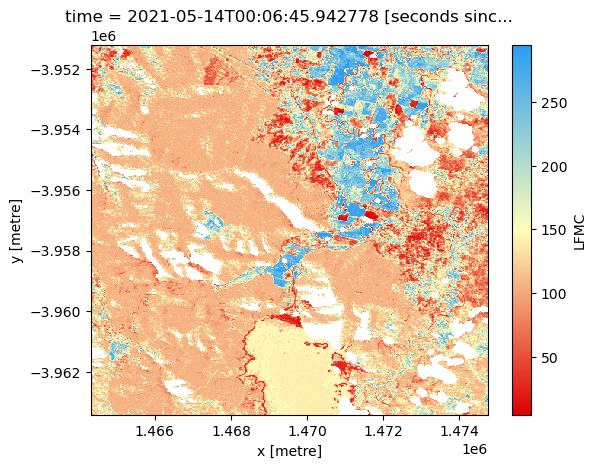

In [25]:
masked_data.LFMC.isel(time=19).plot(cmap=cmap)

In [26]:
masked_data.LFMC

<xarray.DataArray 'LFMC' (time: 21, y: 610, x: 521)> Size: 53MB
array([[[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]],

       [[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
...
        [104.1621484 , 106.84608446, 124.174045  , ..., 126.93140799,
         111.19413063, 119.32877166],
        [106.39845303, 113.87610187, 126.46519746, ..., 140.29150185,
         110.35877858, 139.27105208],
        [151.55321006, 125.91192951, 115.02767458, ..., 120.50240183,
         131.50730705, 111.63885622]],

       [[ 51.29452055,  42.62902641,  36.23093507, ...,          nan,
                  nan,          nan],
        [ 22.99616596,  42.60663504,  47.0050671 , ...,          nan,
                  nan,          nan],
        [ 38.10510063,  38.98721977,  71.38018835, ...,          nan,
                  nan,          nan],
        ...,
        [105.33239121, 109.31631955, 108.27463225, ...,          nan,
                  nan,          nan],
        [113.86149905, 120.47875058, 107.1211088 , ...,          nan,
                  nan,          nan],
        [127.25353579, 114.84541139, 111.45097522, ...,          nan,
                  nan,          nan]]])
Coordinates:
  * x            (x) float64 4kB 1.464e+06 1.464e+06 ... 1.475e+06 1.475e+06
  * y            (y) float64 5kB -3.951e+06 -3.951e+06 ... -3.963e+06 -3.963e+06
  * time         (time) datetime64[ns] 168B 2021-05-02T00:16:23.840514 ... 20...
    spatial_ref  int32 4B 3577

In [27]:
FMC_data_int = FMC_data.astype('int16')
#make the data be a 16 bit int rather than a floating point. 

/env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [28]:

# save to file

write_cog(FMC_data_int.LFMC, fname=f'lfmc_output.tif')

OSError: File exists